# Deep RNNs | Stacked RNNs | Stacked LSTMs | Stacked GRUs

## Importing Libraries

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'
import keras
import matplotlib.pyplot as plt

## Loading the Dataset

In [5]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=5000)

## Padding the Sequences

In [6]:
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=100)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=100)

In [7]:
X_train.shape

(25000, 100)

In [8]:
X_test.shape

(25000, 100)

In [9]:
len(X_train[0])

100

## Deep RNN

In [10]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.SimpleRNN(units=5, return_sequences=True),
        keras.layers.SimpleRNN(units=5),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 5)         │           190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,251 (625.98 KB)

 Trainable params: 160,251 (625.98 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [13]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.5244 - loss: 0.6891 - val_accuracy: 0.6058 - val_loss: 0.6464
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.7017 - loss: 0.5780 - val_accuracy: 0.7292 - val_loss: 0.5498
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.7984 - loss: 0.4445 - val_accuracy: 0.7529 - val_loss: 0.5260
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.8173 - loss: 0.4154 - val_accuracy: 0.6991 - val_loss: 0.6287
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8585 - loss: 0.3485 - val_accuracy: 0.7623 - val_loss: 0.5486
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.8808 - loss: 0.3003 - val_accuracy: 0.7457 - val_loss: 0.5931
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 48ms/step - accuracy: 0.9072 - loss: 0.2534 - val_accuracy: 0.7493 - val_loss: 0.6098
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.9253 - loss: 0.2125 - 

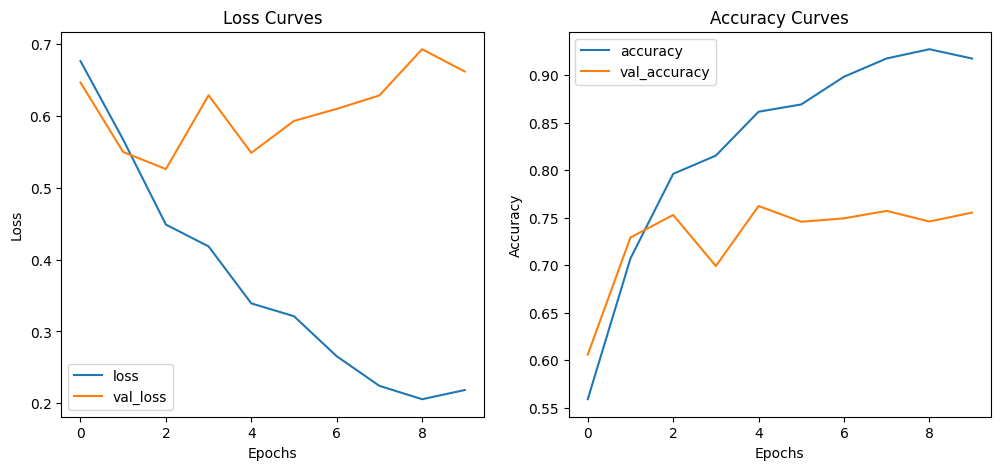

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## LSTM

In [16]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.LSTM(units=5, return_sequences=True),
        keras.layers.LSTM(units=5),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 5)         │           760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5)              │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,986 (628.85 KB)

 Trainable params: 160,986 (628.85 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [20]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - accuracy: 0.6940 - loss: 0.5673 - val_accuracy: 0.8277 - val_loss: 0.3958
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 67ms/step - accuracy: 0.8782 - loss: 0.3053 - val_accuracy: 0.8432 - val_loss: 0.3608
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.9116 - loss: 0.2328 - val_accuracy: 0.8507 - val_loss: 0.3488
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 69ms/step - accuracy: 0.9330 - loss: 0.1852 - val_accuracy: 0.8458 - val_loss: 0.3991
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 66ms/step - accuracy: 0.9474 - loss: 0.1511 - val_accuracy: 0.8411 - val_loss: 0.4154
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9572 - loss: 0.1305 - val_accuracy: 0.8390 - val_loss: 0.4498
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.9683 - loss: 0.1046 - val_accuracy: 0.8343 - val_loss: 0.5210
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.9708 - loss: 0.0934 - 

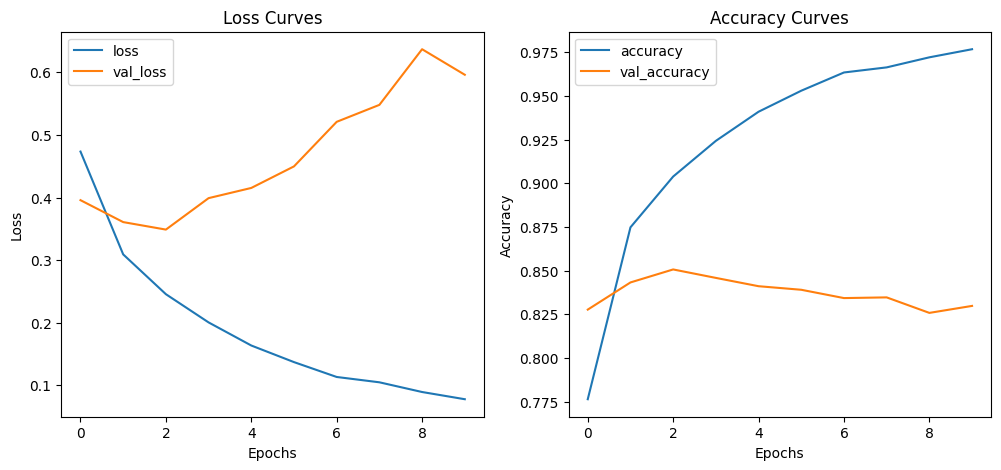

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


## GRU

In [22]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(100,)),
        keras.layers.Embedding(input_dim=5000, output_dim=32),
        keras.layers.GRU(units=5, return_sequences=True),
        keras.layers.GRU(units=5),
        keras.layers.Dense(units=1, activation='sigmoid')
    ]
)

In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 32)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 100, 5)         │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 5)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,771 (628.01 KB)

 Trainable params: 160,771 (628.01 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [25]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 88ms/step - accuracy: 0.6703 - loss: 0.5800 - val_accuracy: 0.8476 - val_loss: 0.3570
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.8783 - loss: 0.3014 - val_accuracy: 0.8500 - val_loss: 0.3506
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.9095 - loss: 0.2373 - val_accuracy: 0.8482 - val_loss: 0.3643
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.9320 - loss: 0.1899 - val_accuracy: 0.8424 - val_loss: 0.3781
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.9490 - loss: 0.1571 - val_accuracy: 0.8342 - val_loss: 0.4407
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step - accuracy: 0.9622 - loss: 0.1241 - val_accuracy: 0.8319 - val_loss: 0.4839
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 100ms/step - accuracy: 0.9714 - loss: 0.0961 - val_accuracy: 0.8297 - val_loss: 0.5455
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.9811 - loss: 0.0677 -

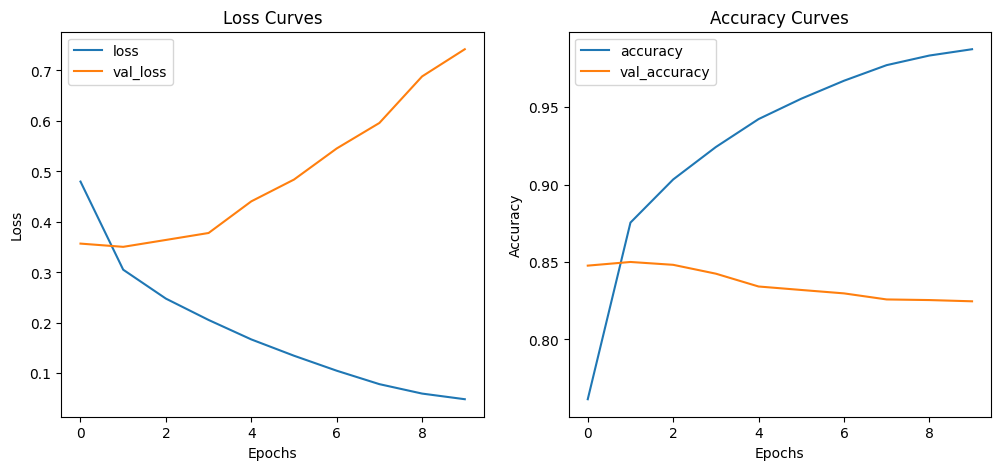

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
